# Manual dice score
def dice(x, y):
    intersect = np.sum(np.sum(np.sum(x * y)))
    y_sum = np.sum(np.sum(np.sum(y)))
    if y_sum == 0:
        return 0.0
    x_sum = np.sum(np.sum(np.sum(x)))
    return 2 * intersect / (x_sum + y_sum)

# Spherical Laplacian Gradient 3D Window
def construct_window(radius, mode='cyclic', weight= 1.):
    """ Constructing window for non-equal supression
    """
    assert radius % 2 != 0
    r = radius // 2

    # add noise to prevent neighbor exclusion
    window = np.ones([radius, radius, radius]) 
    x = np.linspace(-r, r, radius)
    y, z = x.copy(), x.copy()
    xv, yv, zv = np.meshgrid(x, y, z)

    if mode == 'cyclic':
        window[xv**2 + yv**2 + zv**2 >= (r + 0.25) ** 2] = 0
    elif mode == 'cross':
        window *= (xv == 0) | (yv == 0) | (zv == 0)
    elif mode == 'uni-cross':
        x = xv == 0
        y = yv == 0
        z = zv == 0
        window *= (x & y) | (y & z) | (z & x)
    window[r][r][r] = 0
    window /= np.sum(window) 
    window *= weight
    window[r][r][r] = -np.sum(window)

    return window

def laplacian(channel, radius=3, mode='cyclic'):
    conv = 0
    weight = construct_window(radius, mode=mode)
    conv = nn.Conv3d(   in_channel=channel, 
                        out_channel=channel, 
                        padding=channel // 2, 
                        groups=1)
    

In [ ]:
conv = nn.Conv3d(   in_channels=3, 
                    out_channels=3, 
                    kernel_size=3,
                    stride=1,
                    dilation=1,
                    padding=1, 
                    groups=1)

In [ ]:
conv.weight

In [ ]:
conv_weight = construct_window(3, mode='cyclic', weight= 2.)

In [ ]:
conv_weight

In [ ]:
conv.weight = torch.nn.Parameter(torch.from_numpy(conv_weight))

In [ ]:
conv.weight.requires_grad = False

In [ ]:
conv.weight

In [ ]:
class Lambda(nn.Module):
    def __init__(self, lambd):
        super().__init__()
        import types
        assert type(lambd) is types.LambdaType
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)

In [ ]:
normal = lambda matrix: torch.linalg.norm(matrix, ord= None, dim=1, keepdim=True)

In [ ]:
norm = Lambda(normal)

In [ ]:
border_extractor = nn.Sequential(conv, norm)

In [1]:
from typing import Any, Dict, Tuple

import numpy as np
import torch
from torch import nn
from lightning import LightningModule
from torchmetrics import MaxMetric, MeanMetric
from torchmetrics.classification.accuracy import Accuracy
from torch.cuda.amp import GradScaler, autocast

from monai.inferers import sliding_window_inference
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.networks.nets import SwinUNETR 
from monai.transforms import Activations, AsDiscrete, Compose
from monai.utils.enums import MetricReduction
from monai.data import decollate_batch

import numpy as np
import time
import os
import shutil

from functools import partial
import wandb
from omegaconf import DictConfig
import hydra
import rootutils
rootutils.setup_root(search_from=".", indicator='setup.py', pythonpath=True)


PosixPath('/work/hpc/spine-segmentation')

In [2]:
cd ..

/work/hpc/spine-segmentation


In [3]:
pwd

'/work/hpc/spine-segmentation'

In [31]:

with hydra.initialize(version_base="1.3", config_path="../configs", ):
    cfg = hydra.compose(config_name='train.yaml')
    print(cfg)

{'task_name': 'train', 'tags': ['dev'], 'train': True, 'test': True, 'ckpt_path': None, 'seed': None, 'data': {'transform_train': {'_target_': 'monai.transforms.Compose', 'transforms': [{'_target_': 'monai.transforms.LoadImaged', 'keys': ['image', 'label']}, {'_target_': 'src.data.transforms.array.ConvertToMultiChannelBasedOnSpiderClassesdSemantic', 'keys': 'label'}, {'_target_': 'monai.transforms.EnsureChannelFirstd', 'keys': 'image'}, {'_target_': 'monai.transforms.Spacingd', 'keys': ['image', 'label'], 'pixdim': '${data.spacing}', 'mode': [3, 'nearest']}, {'_target_': 'monai.transforms.RandAffined', 'keys': ['image', 'label'], 'prob': 0.15, 'rotate_range': [[-0.1, 0.1], [-0.3, 0.3], [-0.3, 0.3]], 'scale_range': [[-0.05, 0.05], [-0.05, 0.05], [-0.05, 0.05]], 'padding_mode': 'zeros', 'mode': [3, 'nearest']}, {'_target_': 'monai.transforms.RandSimulateLowResolutiond', 'keys': 'image', 'prob': 0.1, 'downsample_mode': 'bilinear', 'upsample_mode': 'trilinear', 'align_corners': True, 'zoom

In [32]:
!export HYDRA_FULL_ERROR=1

In [33]:
cfg.data.batch_size = 2

In [34]:
datamodule = hydra.utils.instantiate(cfg.data)

In [35]:
datamodule.setup()

In [36]:
dataloader = datamodule.val_dataloader()

In [37]:
loader = iter(dataloader)

In [11]:
sample = next(loader)

In [12]:
# from src.data.transforms.array import  PercentileNormalizeIntensityd

In [44]:
# transform = PercentileNormalizeIntensityd(keys='image', allow_missing_keys=False, percentile=[0.05, 0.95], channel_wise=True, nonzero=True)


In [14]:
def _std(percentile, x, mean):
    low, high = 1, 1
    (density, values) = torch.histogram(x, density=True)
    density = torch.tensor(density)
    density = torch.cumsum(density * (values[1:] - values[:-1]), dim=0)
    # print(density)
    values = values[1:]
    low =  values[density > percentile[0]].min()
    high = values[density > percentile[1]].min()
    print(low, mean, high)
    return mean - low, high - mean

In [15]:
mean = torch.mean(sample['image'][0])

In [16]:
low, high = _std([0.05, 0.95], sample['image'][0], mean)

metatensor(-0.9773) metatensor(0.1496) metatensor(1.7978)


/tmp/ipykernel_3377308/2410210565.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  density = torch.tensor(density)


In [17]:
output = transform(sample)

metatensor(1.1269) metatensor(1.6481)


metatensor(1.2750) metatensor(1.5572)


(metatensor(-1.4659), metatensor(3.5484), metatensor(-0.1178))

In [27]:
img = sample['image'][1]
(density, values) = torch.histogram(img, density=True)
dst = density.numpy()
val = values.numpy()
cdf = np.cumsum(dst * (val[1:] - val[:-1]))
print(img.min(), img.max(), img.mean())

metatensor(-1.2503) metatensor(1.5380) metatensor(-0.0633)


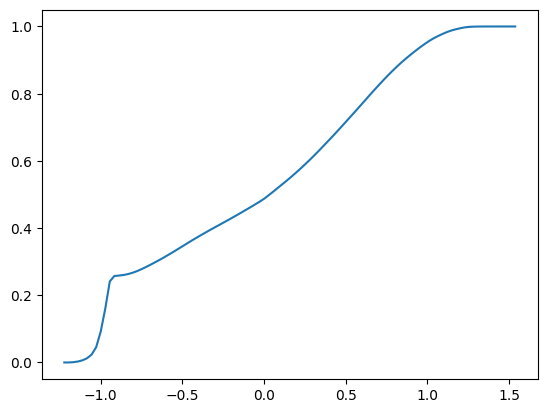

In [28]:
plt.plot(val[1:], cdf)

In [12]:
import matplotlib.pyplot as plt

In [13]:
lower = -10
upper = 20
quantile = 0.2
histogram = np.zeros(int((upper - lower) / quantile))

In [14]:
survey = []

In [39]:
batch = 1
for i in range(len(dataloader)):
    batch = next(loader)
    images = batch['image']
    hist = torch.histogram(images)
    density = hist[0].numpy()
    value = hist[1].numpy()
    cdf = np.cumsum(density / np.sum(density))
    low = np.array(np.where(cdf < 0.05)).max()
    high = np.array(np.where(cdf < 0.95)).max()
    mean = np.mean(images)
    survey.append([value[low], mean, value[high]])
    pos = np.floor((value - lower) / quantile).astype(int)
    histogram[pos[1:]] += density
    print("Next")
    

Next
Next
Next
Next
Next
Next
Next
Next
Next
Next
Next
Next
Next
Next
Next
Next
Next
Next
Next
Next
Next
Next


In [40]:
survey

[[-1.0928398, -0.25516495, 0.9434559],
 [-1.1051626, -0.19590881, 0.8897331],
 [-1.0877262, -0.30767855, 0.9205998],
 [-1.0598854, -0.24327593, 0.9087031],
 [-1.0724028, -0.17811505, 0.9175959],
 [-1.1274419, -0.23591095, 0.93941134],
 [-1.065498, -0.2187349, 0.9128968],
 [-1.0881653, -0.36579096, 0.8920969],
 [-1.0616715, -0.31660223, 0.87789375],
 [-1.0759504, -0.29448596, 0.88729674],
 [-1.0639868, -0.18293262, 0.92464304],
 [-1.0923034, -0.27379954, 0.92551637],
 [-1.0732892, -0.26632577, 0.8625691],
 [-1.0817939, -0.22066242, 0.9423864],
 [-1.112818, -0.31731564, 0.9097116],
 [-1.0810394, -0.20809671, 0.85041183],
 [-1.0875176, -0.307168, 0.9115742],
 [-1.0924016, -0.26124895, 0.9115491],
 [-1.1578238, -0.27045405, 0.89952046],
 [-1.1227105, -0.22215597, 0.7175028],
 [-1.033217, -0.22274704, 0.9025782],
 [-1.0985407, -0.17108805, 0.9268589],
 [-1.0928398, -0.2720957, 0.9434559],
 [-1.1051624, -0.21851565, 0.8897333],
 [-1.0877262, -0.32451847, 0.9205998],
 [-1.0598854, -0.25932592

In [41]:
sorted_hist = np.array(sorted(survey))

In [42]:
a = sorted(survey)

In [43]:
ax = np.arange(0, len(survey), 1)
ax.shape

(43,)

In [44]:
batch['image'].mean()

metatensor(-0.2369)

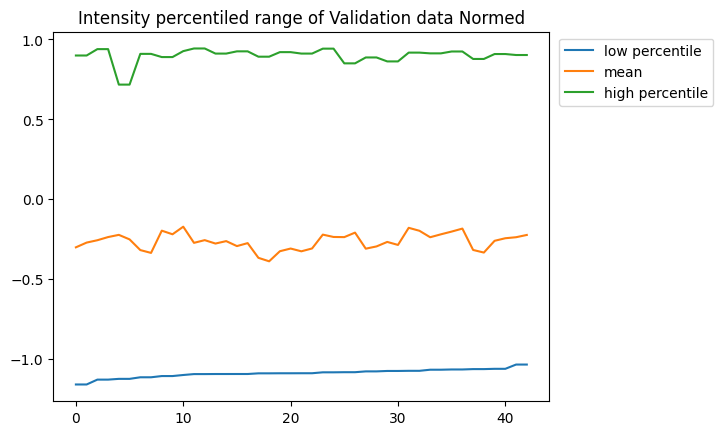

In [45]:
plt.plot(ax, sorted_hist[:, 0], label='low percentile')
plt.plot(ax, sorted_hist[:, 1], label='mean')
plt.plot(ax, sorted_hist[:, 2], label='high percentile')
plt.legend(loc=[1.02, 0.8])
plt.title("Intensity percentiled range of Validation data Normed")
plt.show()

In [46]:
values = np.arange(lower, upper, quantile)
values.shape
values 
cdf = histogram / np.sum(histogram)
cum_cdf = np.cumsum(cdf)

In [47]:
np.sum(cdf == 0)

117

Text(0.5, 1.0, 'Intensity Cumulative Distribution of Training Data Post-Normalize Augmented Normed')

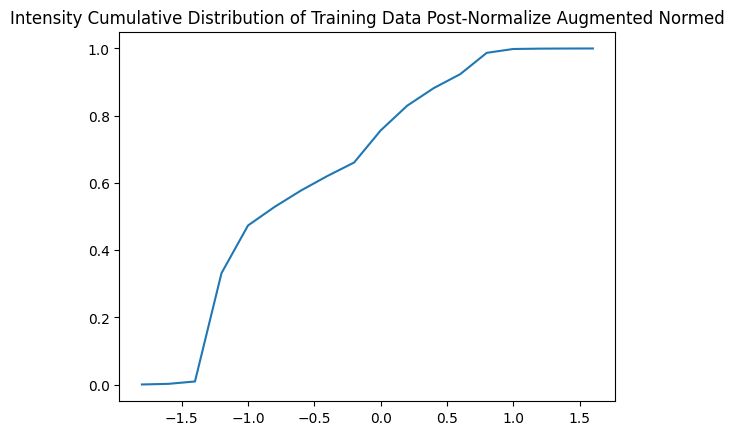

In [48]:
plt.plot(values[cdf > 0.0001], cum_cdf[cdf > 0.0001])
plt.title("Intensity Cumulative Distribution of Training Data Post-Normalize Augmented Normed")

In [11]:
log_hist = np.log(histogram + 1)

NameError: name 'histogram' is not defined

In [75]:
mean = np.sum(values * histogram / np.sum(histogram))

In [76]:
np.sum(log_hist == 0)

639

In [77]:
np.sum(log_hist)

6825.266373979607

In [72]:
mean

0.04803331410719455

In [81]:
std = np.sum((values - mean) ** 2 * log_hist / np.sum(log_hist)) ** 0.5

In [82]:
std, np.exp(std)

(3.7905414980936043, 44.28037152196887)

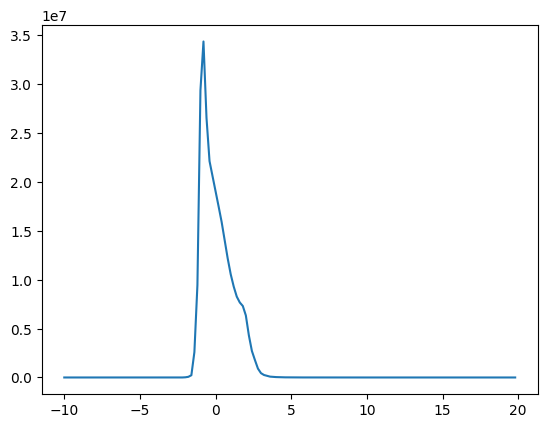

In [41]:
plt.plot(values, histogram)

In [88]:
cdf = histogram / np.sum(histogram)
cdf = np.cumsum(cdf)

In [98]:
np.array(np.where(cdf < 0.9)).max() * quantile + lower

1.4800000000000004

In [ ]:
from src.models.spider_semantic_module import  SpiderLitModule

In [ ]:
model = SpiderLitModule.load_from_checkpoint("/work/hpc/spine-segmentation/logs/train/runs/attention-unet-v2/checkpoints/epoch_271_v2.ckpt")

In [ ]:
iterator = iter(dataloader)

In [ ]:
batch = next(iterator)

In [ ]:
!export CUDA_VISIBLE_DEVICES=0

In [ ]:
net = model.net

In [ ]:
criterion = model.criterion 

In [ ]:
net.to("cuda:0")

In [ ]:
x = batch['image']
x.size()

In [ ]:
x.to("cuda:0")

In [ ]:
type(x)

In [ ]:
model.to("cuda:0")

In [ ]:
x = x.cuda()

In [ ]:
logits = net(x)

In [ ]:
logits.size()

In [ ]:
y = batch['label'].cuda().to("cuda:0")
criterion.to("cuda:0")

In [ ]:
loss = criterion(logits, y)

In [ ]:
loss

In [ ]:
y.size()

In [ ]:
border_extractor.to("cuda:0")

In [ ]:
border = border_extractor(y)

In [ ]:
border.size()

In [ ]:
visual = border.detach().cpu().numpy()

In [ ]:
visual.shape

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
sample = np.sum(visual[0], axis=1)[0]
sample.shape

In [ ]:
visual[visual < 0.1] = 0

In [ ]:
values = np.unique(visual)

In [ ]:
values 

In [ ]:
plt.legend()
plt.imshow(visual[0, 0, :, 201])

In [ ]:
print(visual[0,0,15,201,70])

In [ ]:
import SimpleITK as sitk 

In [ ]:
volume = sitk.GetImageFromArray(visual[0, 0])

In [ ]:
writer = sitk.ImageFileWriter()
writer.SetFileName("/work/hpc/spine-segmentation/outputs/dummy/border.nii.gz")
writer.Execute(volume)

In [ ]:
model.cpu()

In [ ]:
x.detach().cpu()

In [ ]:
y.detach().cpu()

In [ ]:
logits.detach().cpu()

In [ ]:
del x, y, logits, model, border_extractor